<a href="https://colab.research.google.com/github/FrankArcosAnselmo/mI_lab01_Fa/blob/develop/LAB14_ARCOS_FRANK.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LABORATORIO 14
## NOMBRE: ARCOS ANSELMO FRANK FERNANDO RODOLFO

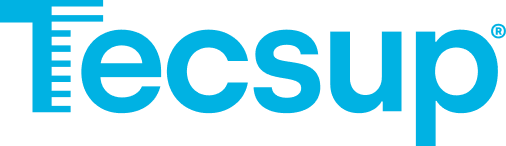

### A) Realice el preprocesamiento de la información que incluya el análisis de datos faltantes y tratamiento de outliers a nivel univariado y multivariado. Además, convierta las variables categóricas a dummies y aplique un escalamiento a las variables numéricas

In [2]:
import pandas as pd

# Cargar el dataset
df = pd.read_csv("/content/drive/MyDrive/BIG DATA Y CIENCIAS DE DATOS/MINERIA DE DATOS/garments_worker_productivity.csv")

# Eliminar la columna 'date'
df.drop(columns=['date'], inplace=True)


In [3]:
print(df.isnull().sum())
df.dropna(inplace=True)  # o usar imputación si prefieres


quarter                    0
department                 0
day                        0
team                       0
targeted_productivity      0
smv                        0
wip                      506
over_time                  0
incentive                  0
idle_time                  0
idle_men                   0
no_of_style_change         0
no_of_workers              0
actual_productivity        0
dtype: int64


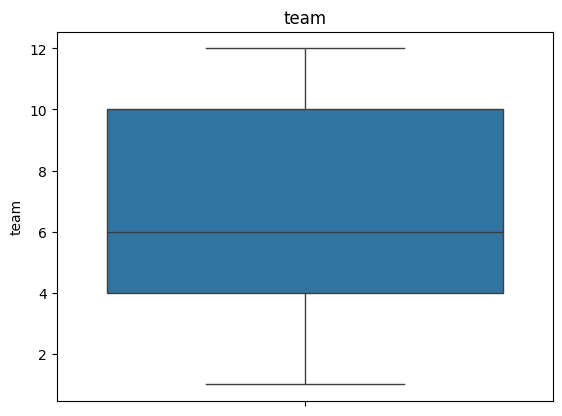

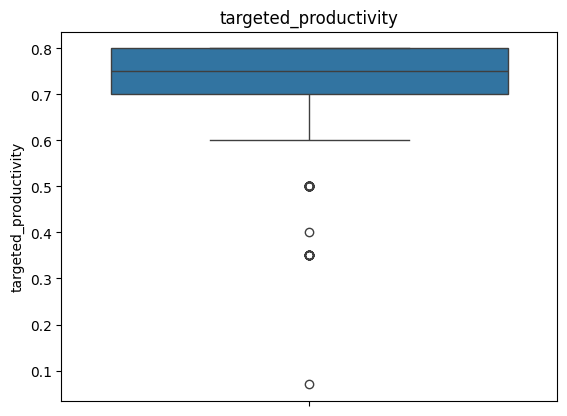

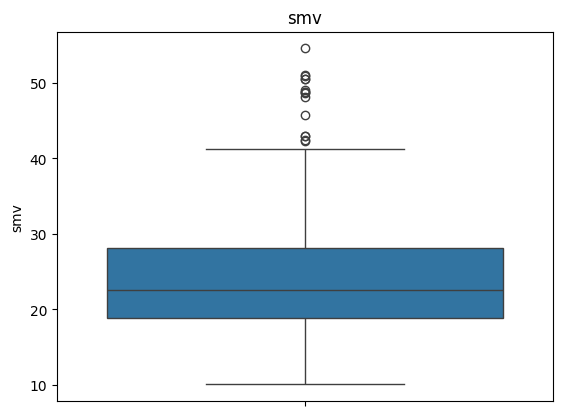

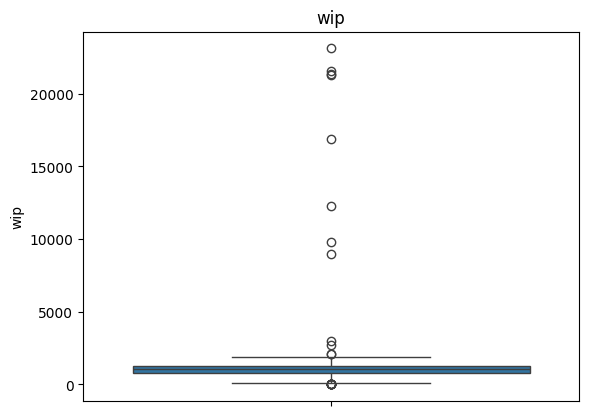

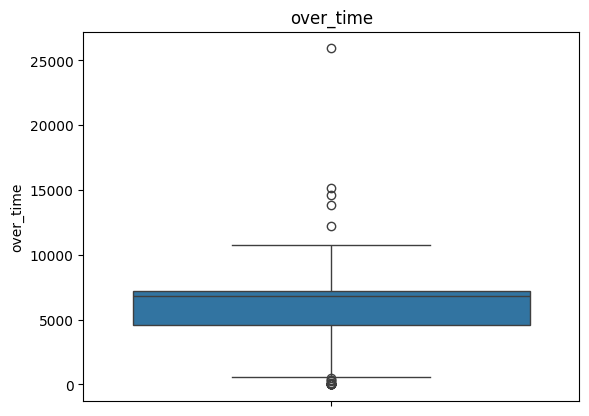

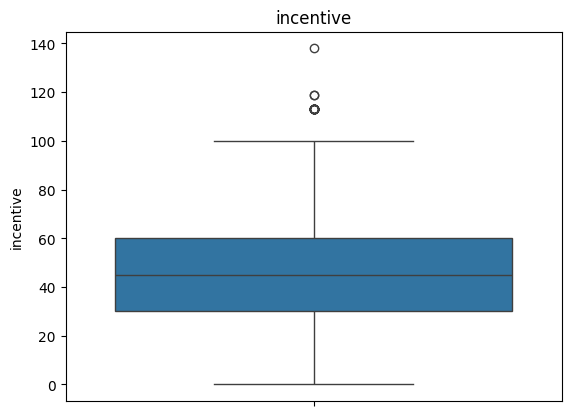

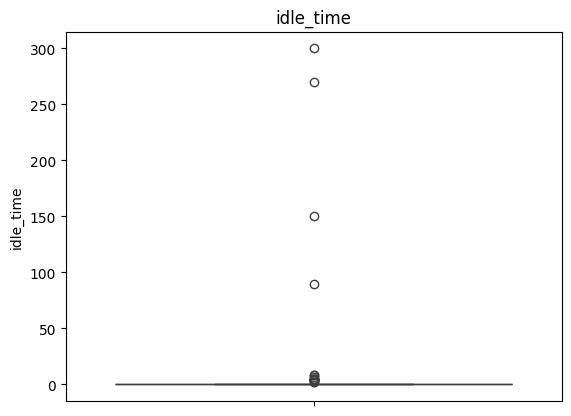

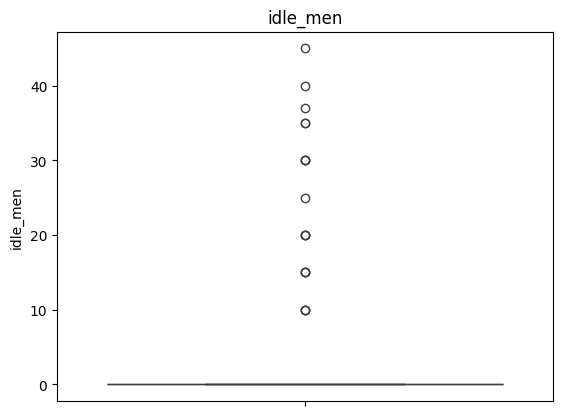

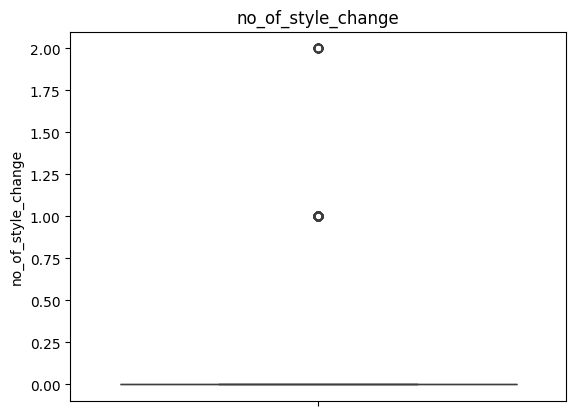

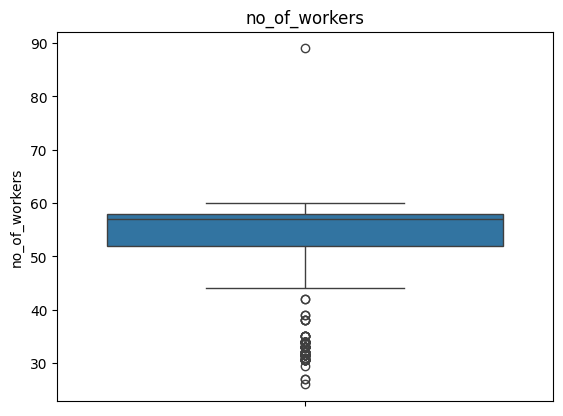

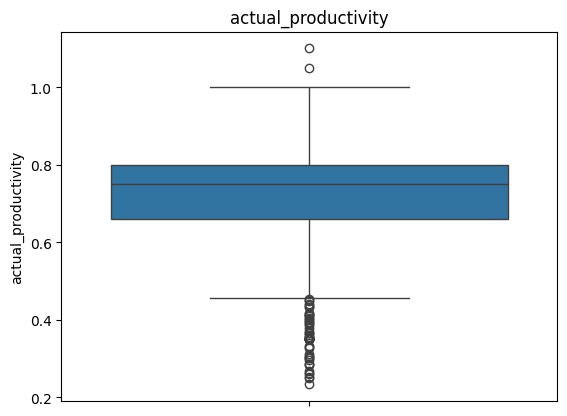

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

# Univariado: Boxplot de variables numéricas
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
for col in num_cols:
    sns.boxplot(df[col])
    plt.title(col)
    plt.show()

# Multivariado: Usando Isolation Forest
from sklearn.ensemble import IsolationForest

iso = IsolationForest(contamination=0.05)
outliers = iso.fit_predict(df[num_cols])
df = df[outliers == 1]


In [5]:
df = pd.get_dummies(df, drop_first=True)

In [6]:
from sklearn.preprocessing import StandardScaler

X = df.drop(columns=['actual_productivity'])
y = df['actual_productivity']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


B) Separe los datos en entrenamiento (80%) y prueba (20%) y, realice un ensamblaje utilizando
las técnicas de voting, bagging, boosting y stacking para los modelos k-NN, SVM, regresión
lineal, árbol de clasificación y Random Forest definiendo distintos hiperparámetros para cada
modelo

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [8]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

models = {
    'lr': LinearRegression(),
    'knn': KNeighborsRegressor(n_neighbors=5),
    'svm': SVR(C=1.0, epsilon=0.1),
    'tree': DecisionTreeRegressor(max_depth=5),
    'rf': RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
}

### 3. Ensamblajes

a) Voting Regressor
python
Copiar
Editar

In [9]:
from sklearn.ensemble import VotingRegressor

voting = VotingRegressor(estimators=[
    ('lr', models['lr']),
    ('knn', models['knn']),
    ('svm', models['svm']),
    ('tree', models['tree']),
    ('rf', models['rf'])
])
voting.fit(X_train, y_train)


VotingRegressor(estimators=[('lr', LinearRegression()),
                            ('knn', KNeighborsRegressor()), ('svm', SVR()),
                            ('tree', DecisionTreeRegressor(max_depth=5)),
                            ('rf',
                             RandomForestRegressor(max_depth=5,
                                                   random_state=42))])

b) Bagging



In [18]:
from sklearn.ensemble import BaggingRegressor

bagging = BaggingRegressor(estimator=models['tree'], n_estimators=50, random_state=42)
bagging.fit(X_train, y_train)



BaggingRegressor(estimator=DecisionTreeRegressor(max_depth=5), n_estimators=50,
                 random_state=42)

c) Boosting (usamos XGBoost)


In [11]:
from xgboost import XGBRegressor

boosting = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
boosting.fit(X_train, y_train)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=5, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=100, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

d) Stacking

In [13]:
from sklearn.ensemble import StackingRegressor

stacking = StackingRegressor(
    estimators=[('lr', models['lr']), ('rf', models['rf']), ('knn', models['knn'])],
    final_estimator=RandomForestRegressor(n_estimators=50, random_state=42)
)
stacking.fit(X_train, y_train)


StackingRegressor(estimators=[('lr', LinearRegression()),
                              ('rf',
                               RandomForestRegressor(max_depth=5,
                                                     random_state=42)),
                              ('knn', KNeighborsRegressor())],
                  final_estimator=RandomForestRegressor(n_estimators=50,
                                                        random_state=42))

C) Utilice las métricas error cuadrático medio, raíz del error cuadrático medio, error absoluto
medio y coeficiente de determinación para elegir el mejor modelo que prediga a la variable
‘actual_productivity’, justificando su respuesta.


In [16]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

def evaluar_modelo(nombre, modelo):
    y_pred = modelo.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    print(f"{nombre}:\n MSE={mse:.4f}, RMSE={rmse:.4f}, MAE={mae:.4f}, R2={r2:.4f}\n")


In [19]:
evaluar_modelo("Voting", voting)
evaluar_modelo("Bagging", bagging)
evaluar_modelo("Boosting", boosting)
evaluar_modelo("Stacking", stacking)

Voting:
 MSE=0.0069, RMSE=0.0831, MAE=0.0515, R2=0.7019

Bagging:
 MSE=0.0072, RMSE=0.0848, MAE=0.0464, R2=0.6896

Boosting:
 MSE=0.0056, RMSE=0.0749, MAE=0.0391, R2=0.7577

Stacking:
 MSE=0.0067, RMSE=0.0817, MAE=0.0450, R2=0.7112

